In [ ]:
import warnings
warnings.filterwarnings('ignore')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, ConfusionMatrixDisplay,
    hamming_loss,
)

import keras
from keras import layers

from transformers import pipeline as hf_pipeline

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
plt.style.use('dark_background')

# ── Config ──
N_PER_CAT         = 250    # papers per top-level archive in equal subsample
MAX_EMB_LEN       = 256    # BERT token truncation
RANDOM_STATE      = 42
MIN_ARCHIVE_COUNT = N_PER_CAT   # archive must have ≥ this many papers to include

# CATS and TAU are derived in § 3 once the archive set is known

# § 2 — Load data

In [2]:
path = 'C:/Users/Graham West/Python Notebooks/Meharry Teaching/Datasets/arXiv/arxiv-metadata-oai-snapshot.json'

# arXiv fields: id, submitter, authors, title, comments,
# journal-ref, doi, abstract, categories, versions, update_date
keep_cols = ['title', 'abstract', 'categories']

chunks = []
i = 0
for chunk in pd.read_json(path, lines=True, chunksize=50_000):
    chunks.append(chunk[keep_cols])
    i += 1
    if i >= 5:
        break

df = pd.concat(chunks, ignore_index=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   title       250000 non-null  object
 1   abstract    250000 non-null  object
 2   categories  250000 non-null  object
dtypes: object(3)
memory usage: 5.7+ MB


# § 3 — Normalize categories → top-level archives

In [3]:
from collections import Counter

# ── Parse space-separated category strings → unique top-level archives ──
def top_levels(s):
    """'cs.AI cs.LG' → ['cs']   |   'math.NA cs.NA' → ['cs', 'math']"""
    codes = str(s).split()
    return sorted(set(c.split('.')[0] for c in codes))

df['archives'] = df['categories'].map(top_levels)

# ── Archive prevalence (each archive counted once per paper) ──
archive_counts = Counter(
    arc for arcs in df['archives'] for arc in arcs
)
print(f"Total unique top-level archives: {len(archive_counts)}")

# Keep only archives with enough papers to equal-subsample from
CATS = sorted(
    arc for arc, cnt in archive_counts.items()
    if cnt >= MIN_ARCHIVE_COUNT
)
TAU = 1 / len(CATS)

print(f"\nKept archives (n={len(CATS)}, TAU={TAU:.4f}):")
print(CATS)

# ── Human-readable archive names ──
KEY2TOPIC = {
    'astro-ph': 'Astrophysics',
    'cond-mat': 'Condensed Matter',
    'cs':       'Computer Science',
    'econ':     'Economics',
    'eess':     'Electrical Eng. & Signal Processing',
    'gr-qc':    'General Relativity & Quantum Cosmology',
    'hep-ex':   'High Energy Physics – Experiment',
    'hep-lat':  'High Energy Physics – Lattice',
    'hep-ph':   'High Energy Physics – Phenomenology',
    'hep-th':   'High Energy Physics – Theory',
    'math':     'Mathematics',
    'math-ph':  'Mathematical Physics',
    'nlin':     'Nonlinear Sciences',
    'nucl-ex':  'Nuclear Physics – Experiment',
    'nucl-th':  'Nuclear Physics – Theory',
    'physics':  'Physics',
    'q-bio':    'Quantitative Biology',
    'q-fin':    'Quantitative Finance',
    'quant-ph': 'Quantum Physics',
    'stat':     'Statistics',
}
KEY2TOPIC = {k: v for k, v in KEY2TOPIC.items() if k in CATS}

Total unique top-level archives: 20

Kept archives (n=18, TAU=0.0556):
['astro-ph', 'cond-mat', 'cs', 'gr-qc', 'hep-ex', 'hep-lat', 'hep-ph', 'hep-th', 'math', 'math-ph', 'nlin', 'nucl-ex', 'nucl-th', 'physics', 'q-bio', 'q-fin', 'quant-ph', 'stat']


# § 4 — EDA

In [4]:
# ── Prevalence bar chart ──
arc_series = pd.Series(archive_counts)
arc_series = arc_series[arc_series.index.isin(CATS)].sort_values(ascending=False)
arc_series = arc_series / arc_series.sum()  # normalize to proportions
arc_series

math        0.211994
astro-ph    0.146424
cond-mat    0.140669
physics     0.069437
hep-ph      0.068694
cs          0.065376
hep-th      0.064116
quant-ph    0.049643
gr-qc       0.040770
math-ph     0.035257
nucl-th     0.021592
hep-ex      0.018914
nlin        0.014710
stat        0.014243
q-bio       0.012798
nucl-ex     0.010324
hep-lat     0.010248
q-fin       0.004793
dtype: float64

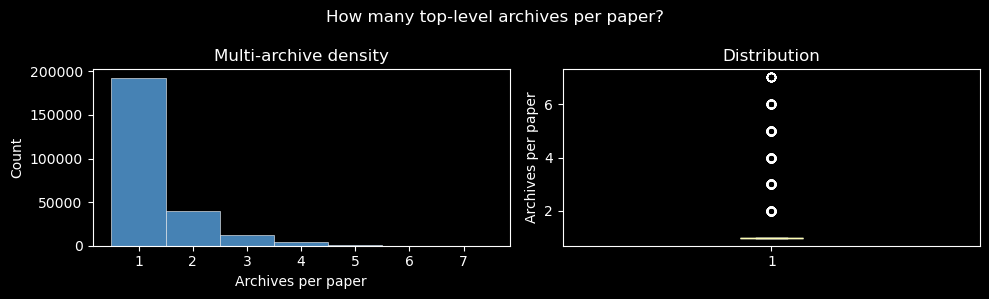

archives
1    192721
2     40077
3     12722
4      3852
5       546
6        69
7        13
Name: count, dtype: int64


In [5]:
# ── Archives per paper distribution ──
n_arcs = df['archives'].map(len)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(n_arcs, bins=range(1, n_arcs.max() + 2), align='left',
             color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_xlabel('Archives per paper')
axes[0].set_ylabel('Count')
axes[0].set_title('Multi-archive density')

axes[1].boxplot(n_arcs, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue'))
axes[1].set_ylabel('Archives per paper')
axes[1].set_title('Distribution')

fig.suptitle('How many top-level archives per paper?')
plt.tight_layout()
plt.show()
print(n_arcs.value_counts().sort_index())

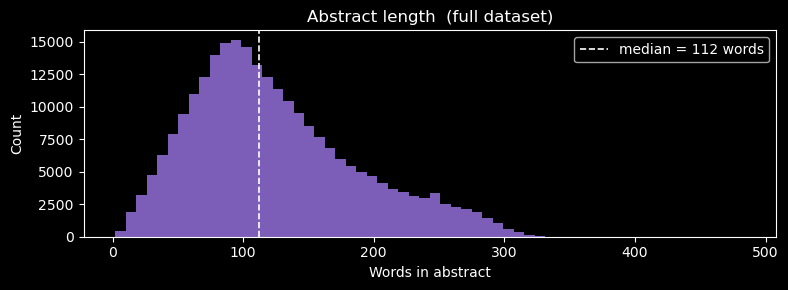

── Random examples ──

[astro-ph]  →  top-level: ['astro-ph']
  TITLE:    Probing FSR star cluster candidates in bulge/disk directions with 2MASS
  colour-magnitude diagrams
  ABSTRACT: We analyse 20 star cluster candidates projected mostly in the bulge direction
($|\ell|<60^\circ$). The sample contains all candidates in that sector
classified by \citet{FSRcat} with quality flags denoting high probability of
being star clusters. B…

[hep-ph]  →  top-level: ['hep-ph']
  TITLE:    Further Development of the Tetron Model
  ABSTRACT: After a prologue which clarifies some issues left open in my last paper, the
main features of the tetron model of elementary particles are discussed in the
light of recent developments, in particular the formation of strong and
electroweak vector b…

[physics.atom-ph]  →  top-level: ['physics']
  TITLE:    Characterisation of a three-dimensional Brownian motor in optical
  lattices
  ABSTRACT: We present here a detailed study of the behaviour of a three dimens

In [6]:
# ── Abstract word-count distribution ──
wc = df['abstract'].fillna('').str.split().str.len()

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(wc, bins=60, color='mediumpurple', edgecolor='none', alpha=0.85)
ax.axvline(wc.median(), color='white', linestyle='--', linewidth=1.2,
           label=f'median = {wc.median():.0f} words')
ax.set_xlabel('Words in abstract')
ax.set_ylabel('Count')
ax.set_title('Abstract length  (full dataset)')
ax.legend()
plt.tight_layout()
plt.show()

# ── 3 random examples ──
print("── Random examples ──")
for _, row in df.dropna(subset=['title', 'abstract']).sample(3, random_state=RANDOM_STATE).iterrows():
    print(f"\n[{row['categories']}]  →  top-level: {row['archives']}")
    print(f"  TITLE:    {row['title'][:120]}")
    print(f"  ABSTRACT: {row['abstract'][:250].strip()}…")

# § 5 — Filter, subsample, build target

In [7]:
arc_series = arc_series[ arc_series >= 0.04]  # filter to archives with >1% prevalence
arc_series

math        0.211994
astro-ph    0.146424
cond-mat    0.140669
physics     0.069437
hep-ph      0.068694
cs          0.065376
hep-th      0.064116
quant-ph    0.049643
gr-qc       0.040770
dtype: float64

In [8]:
# remove any multi-archive papers and keep only the top-level archives of interest
df = df[df['archives'].map(len) == 1]

In [9]:
# filter by abstract length
df = df[df['abstract'].fillna('').str.split().str.len() >= 50]
df = df[df['abstract'].fillna('').str.split().str.len() <= 300]

In [10]:
df

,title,abstract,categories,archives
0,Calculation of prompt diphoton production cros...,A fully differential calculation in perturba...,hep-ph,[hep-ph]
2,The evolution of the Earth-Moon system based o...,The evolution of Earth-Moon system is descri...,physics.gen-ph,[physics]
5,Bosonic characters of atomic Cooper pairs acro...,We study the two-particle wave function of p...,cond-mat.mes-hall,[cond-mat]
6,Polymer Quantum Mechanics and its Continuum Limit,A rather non-standard quantum representation...,gr-qc,[gr-qc]
7,Numerical solution of shock and ramp compressi...,A general formulation was developed to repre...,cond-mat.mtrl-sci,[cond-mat]
...,...,...,...,...
249993,"Some radicals, Frattini and Cartan Subalgebras...",In the present work we introduce notions suc...,math.RA,[math]
249995,Bruno Touschek: particle physicist and father ...,This article gives a brief outline of the li...,physics.hist-ph,[physics]
249996,The Advanced LIGO Gravitational Wave Detector,The Advanced LIGO gravitational wave detecto...,gr-qc,[gr-qc]
249998,Maximal supergravity in three dimensions: supe...,The maximal supergravity theory in three dim...,hep-th,[hep-th]


In [11]:
dfs = []
for cat in arc_series.index:
    df_samp = df[df.categories.str.startswith(cat)].sample(n=N_PER_CAT, random_state=RANDOM_STATE)
    dfs.append(df_samp)
df = pd.concat(dfs, ignore_index=True)
df

,title,abstract,categories,archives
0,"Filtration, automorphisms and classification o...",The principal filtration of the infinite-dim...,math.RA,[math]
1,An Alternative Presentation of the Symmetric-S...,The category Fin of symmetric-simplicial ope...,math.AT,[math]
2,On Potential Function of Gradient Steady Ricci...,In this paper we study potential function of...,math.DG,[math]
3,Motivic zeta functions for degenerations of ab...,This is a survey on motivic zeta functions a...,math.AG,[math]
4,Rational functions admitting double decomposition,J.Ritt has investigated the structure of com...,math.CV,[math]
...,...,...,...,...
2245,Rotation and pseudo-rotation,Eigenvectors of stress-energy tensor (the so...,gr-qc,[gr-qc]
2246,Tortoise coordinate and Hawking effect in the ...,Hawking effect from the Kinnersley spacetime...,gr-qc,[gr-qc]
2247,"General relativity, Lauricella's hypergeometri...",The exact (closed form) solutions of the equ...,gr-qc,[gr-qc]
2248,Connection between Fermionic Strings and Quant...,We present physical arguments based on loop ...,gr-qc,[gr-qc]


In [12]:
# ── Text: title + abstract ──
texts = (df['title'].str.strip() + '\n' + df['abstract'].str.strip()).tolist()

# Rebuild CATS and TAU from the §5-filtered archive set
CATS      = arc_series.index.tolist()
TAU       = 1 / len(CATS)
n_classes = len(CATS)

# Integer index for each paper's (single) archive
cat2idx = {c: i for i, c in enumerate(CATS)}
y_dom   = np.array([cat2idx[a] for a in df['archives'].str[0]])

# One-hot label matrices (all papers are single-archive after §5 filter)
Y_raw  = np.zeros((len(df), n_classes), dtype=int)
Y_raw[np.arange(len(df)), y_dom] = 1
Y_dist = Y_raw.astype(float)   # row sums to 1; matches softmax output shape

# Stratified train/test split
idx_tr, idx_te = train_test_split(
    np.arange(len(df)), test_size=0.2,
    stratify=y_dom, random_state=RANDOM_STATE,
)

# § 6 — Generate embeddings

Five scientific embedding models are compared.  Each text is passed through a HuggingFace
`feature-extraction` pipeline; the last hidden state is mean-pooled over tokens (truncated at
128 tokens) to produce a fixed-size vector.

> ⚠️  **Slow cell on CPU** — ~1 000 texts × 5 models ≈ 40–70 min.  Run once and keep the kernel alive.

In [13]:
# ── Scientific transformer models to compare ──
BERT_MODELS = {
    'BERT-base': 'bert-base-uncased',
    'SciBERT':   'allenai/scibert_scivocab_uncased',
    'SPECTER':   'allenai/specter',
    'SciNCL':    'malteos/scincl',
    'MiniLM':    'sentence-transformers/all-MiniLM-L6-v2',
}

def embed_texts_hf(model_name, texts, max_len=MAX_EMB_LEN, log_every=25):
    """HuggingFace feature-extraction pipeline → mean-pool → (N, hidden_dim) array."""
    pipe = hf_pipeline('feature-extraction', model=model_name)
    vecs = []
    for i, t in enumerate(texts):
        out = np.array(
            pipe(t, tokenize_kwargs={'truncation': True, 'max_length': max_len})
        )[0]                           # drop batch dim → (n_tokens, hidden_dim)
        vecs.append(out.mean(axis=0))  # mean-pool over tokens → (hidden_dim,)
        if (i + 1) % log_every == 0:
            print(f'    [{i+1}/{len(texts)}]')
    return np.vstack(vecs)

In [14]:
embeddings = {}
for short_name, model_id in BERT_MODELS.items():
    print(f'\n── {short_name}  ({model_id}) ──')
    E = embed_texts_hf(model_id, texts)
    embeddings[short_name] = E
    print(f'   shape: {E.shape}')


── BERT-base  (bert-base-uncased) ──


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    [25/2250]
    [50/2250]
    [75/2250]
    [100/2250]
    [125/2250]
    [150/2250]
    [175/2250]
    [200/2250]
    [225/2250]
    [250/2250]
    [275/2250]
    [300/2250]
    [325/2250]
    [350/2250]
    [375/2250]
    [400/2250]
    [425/2250]
    [450/2250]
    [475/2250]
    [500/2250]
    [525/2250]
    [550/2250]
    [575/2250]
    [600/2250]
    [625/2250]
    [650/2250]
    [675/2250]
    [700/2250]
    [725/2250]
    [750/2250]
    [775/2250]
    [800/2250]
    [825/2250]
    [850/2250]
    [875/2250]
    [900/2250]
    [925/2250]
    [950/2250]
    [975/2250]
    [1000/2250]
    [1025/2250]
    [1050/2250]
    [1075/2250]
    [1100/2250]
    [1125/2250]
    [1150/2250]
    [1175/2250]
    [1200/2250]
    [1225/2250]
    [1250/2250]
    [1275/2250]
    [1300/2250]
    [1325/2250]
    [1350/2250]
    [1375/2250]
    [1400/2250]
    [1425/2250]
    [1450/2250]
    [1475/2250]
    [1500/2250]
    [1525/2250]
    [1550/2250]
    [1575/2250]
    [1600/2250]
    [1625/2250]
  

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

    [25/2250]
    [50/2250]
    [75/2250]
    [100/2250]
    [125/2250]
    [150/2250]
    [175/2250]
    [200/2250]
    [225/2250]
    [250/2250]
    [275/2250]
    [300/2250]
    [325/2250]
    [350/2250]
    [375/2250]
    [400/2250]
    [425/2250]
    [450/2250]
    [475/2250]
    [500/2250]
    [525/2250]
    [550/2250]
    [575/2250]
    [600/2250]
    [625/2250]
    [650/2250]
    [675/2250]
    [700/2250]
    [725/2250]
    [750/2250]
    [775/2250]
    [800/2250]
    [825/2250]
    [850/2250]
    [875/2250]
    [900/2250]
    [925/2250]
    [950/2250]
    [975/2250]
    [1000/2250]
    [1025/2250]
    [1050/2250]
    [1075/2250]
    [1100/2250]
    [1125/2250]
    [1150/2250]
    [1175/2250]
    [1200/2250]
    [1225/2250]
    [1250/2250]
    [1275/2250]
    [1300/2250]
    [1325/2250]
    [1350/2250]
    [1375/2250]
    [1400/2250]
    [1425/2250]
    [1450/2250]
    [1475/2250]
    [1500/2250]
    [1525/2250]
    [1550/2250]
    [1575/2250]
    [1600/2250]
    [1625/2250]
  

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

    [25/2250]
    [50/2250]
    [75/2250]
    [100/2250]
    [125/2250]
    [150/2250]
    [175/2250]
    [200/2250]
    [225/2250]
    [250/2250]
    [275/2250]
    [300/2250]
    [325/2250]
    [350/2250]
    [375/2250]
    [400/2250]
    [425/2250]
    [450/2250]
    [475/2250]
    [500/2250]
    [525/2250]
    [550/2250]
    [575/2250]
    [600/2250]
    [625/2250]
    [650/2250]
    [675/2250]
    [700/2250]
    [725/2250]
    [750/2250]
    [775/2250]
    [800/2250]
    [825/2250]
    [850/2250]
    [875/2250]
    [900/2250]
    [925/2250]
    [950/2250]
    [975/2250]
    [1000/2250]
    [1025/2250]
    [1050/2250]
    [1075/2250]
    [1100/2250]
    [1125/2250]
    [1150/2250]
    [1175/2250]
    [1200/2250]
    [1225/2250]
    [1250/2250]
    [1275/2250]
    [1300/2250]
    [1325/2250]
    [1350/2250]
    [1375/2250]
    [1400/2250]
    [1425/2250]
    [1450/2250]
    [1475/2250]
    [1500/2250]
    [1525/2250]
    [1550/2250]
    [1575/2250]
    [1600/2250]
    [1625/2250]
  

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

    [25/2250]
    [50/2250]
    [75/2250]
    [100/2250]
    [125/2250]
    [150/2250]
    [175/2250]
    [200/2250]
    [225/2250]
    [250/2250]
    [275/2250]
    [300/2250]
    [325/2250]
    [350/2250]
    [375/2250]
    [400/2250]
    [425/2250]
    [450/2250]
    [475/2250]
    [500/2250]
    [525/2250]
    [550/2250]
    [575/2250]
    [600/2250]
    [625/2250]
    [650/2250]
    [675/2250]
    [700/2250]
    [725/2250]
    [750/2250]
    [775/2250]
    [800/2250]
    [825/2250]
    [850/2250]
    [875/2250]
    [900/2250]
    [925/2250]
    [950/2250]
    [975/2250]
    [1000/2250]
    [1025/2250]
    [1050/2250]
    [1075/2250]
    [1100/2250]
    [1125/2250]
    [1150/2250]
    [1175/2250]
    [1200/2250]
    [1225/2250]
    [1250/2250]
    [1275/2250]
    [1300/2250]
    [1325/2250]
    [1350/2250]
    [1375/2250]
    [1400/2250]
    [1425/2250]
    [1450/2250]
    [1475/2250]
    [1500/2250]
    [1525/2250]
    [1550/2250]
    [1575/2250]
    [1600/2250]
    [1625/2250]
  

# § 7 — Embedding visualization

In [15]:
n_cats  = len(CATS)
cmap    = plt.cm.get_cmap('tab20', n_cats)
colors  = [cmap(i) for i in range(n_cats)]
topic_labels = [KEY2TOPIC.get(c, c) for c in CATS]
legend_patches = [
    mpatches.Patch(color=colors[i], label=f'{CATS[i]} – {topic_labels[i]}')
    for i in range(n_cats)
]
model_names = list(embeddings.keys())

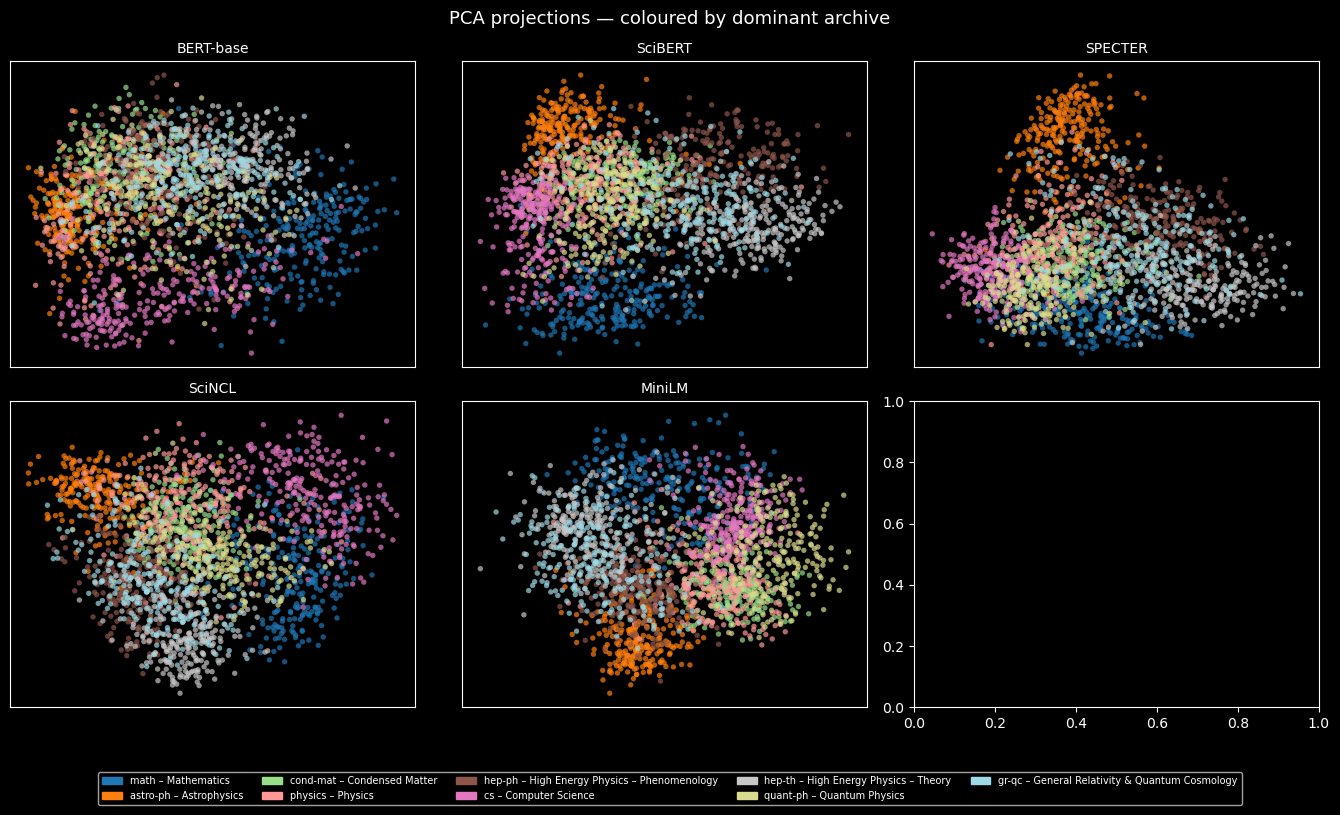

In [16]:
# ── PCA projections ──
n_models = len(model_names)
ncols = 3
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 4))
axes_flat = axes.flat if hasattr(axes, 'flat') else [axes]

for ax, name in zip(axes_flat, model_names):
    E    = embeddings[name]
    proj = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(E)
    ax.scatter(proj[:, 0], proj[:, 1],
               c=[colors[i] for i in y_dom], s=15, alpha=0.7, linewidths=0)
    ax.set_title(name, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

for ax in list(axes_flat)[n_models:]:
    ax.set_visible(False)

fig.legend(handles=legend_patches, loc='lower center',
           ncol=min(5, n_cats), fontsize=7, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('PCA projections — coloured by dominant archive', fontsize=13)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

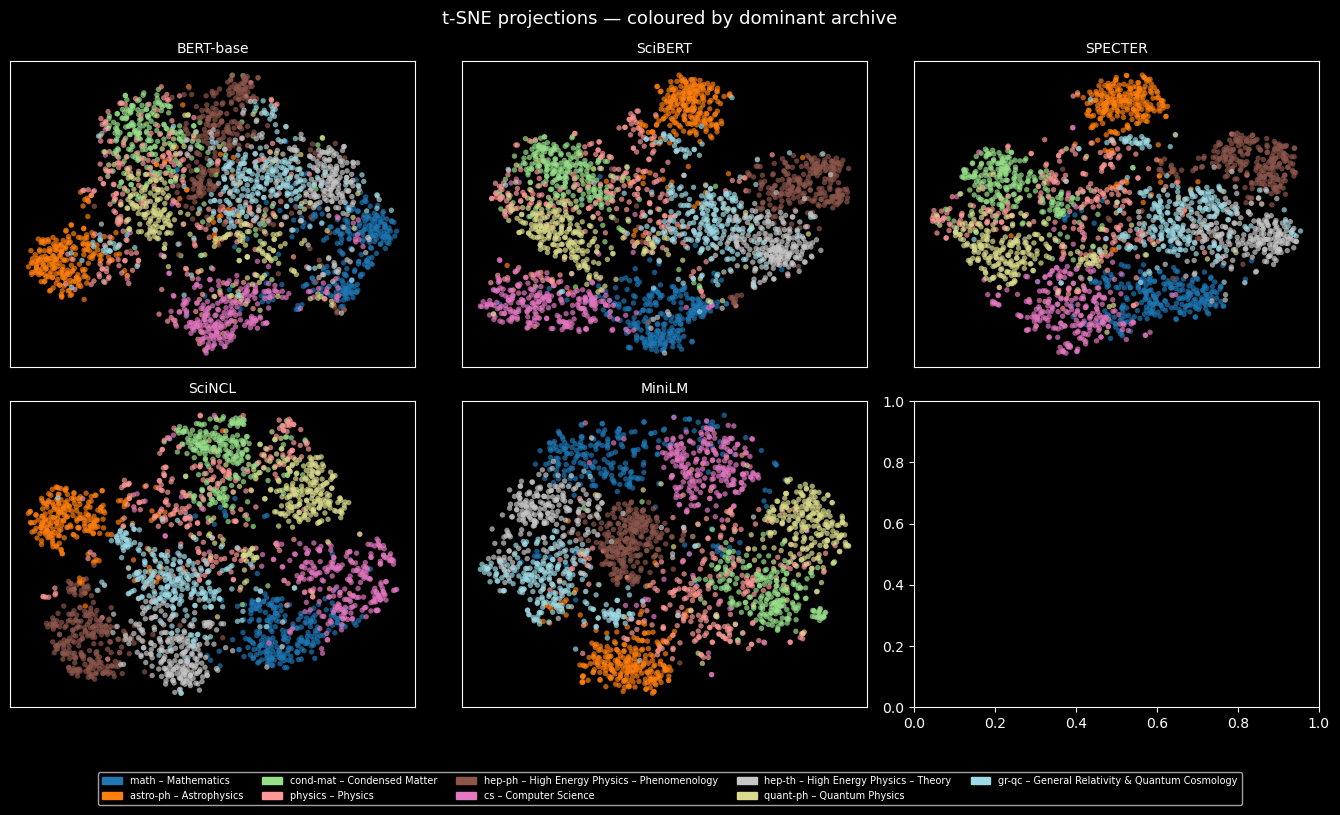

In [17]:
# ── t-SNE projections ──
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 4))
axes_flat = axes.flat if hasattr(axes, 'flat') else [axes]

for ax, name in zip(axes_flat, model_names):
    E    = embeddings[name]
    proj = TSNE(n_components=2, perplexity=30, init='pca',
                random_state=RANDOM_STATE).fit_transform(E)
    ax.scatter(proj[:, 0], proj[:, 1],
               c=[colors[i] for i in y_dom], s=15, alpha=0.7, linewidths=0)
    ax.set_title(name, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

for ax in list(axes_flat)[n_models:]:
    ax.set_visible(False)

fig.legend(handles=legend_patches, loc='lower center',
           ncol=min(5, n_cats), fontsize=7, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('t-SNE projections — coloured by dominant archive', fontsize=13)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

# § 8 — Keras dense net with KL-divergence loss

Architecture: `Dense(256, relu) → Dropout(0.3) → Dense(128, relu) → Dense(n_archives, softmax)`

Row-normalised label vectors (`Y_dist`) are the training target.  Because the softmax output and
`Y_dist` are both probability distributions, **KL-divergence** is the natural loss.  For
single-label papers `Y_dist` is a one-hot vector, so KL-divergence reduces to cross-entropy —
the framing is consistent across the full multi/single-label mix.

In [18]:
n_classes = len(CATS)

def build_model(input_dim, n_classes=n_classes):
    """Small dense classifier with KL-divergence loss."""
    inp = keras.Input(shape=(input_dim,))
    x   = layers.Dense(256, activation='relu')(inp)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    model = keras.Model(inp, out)
    model.compile(
        optimizer='adam',
        loss=keras.losses.KLDivergence(),
        metrics=['mae'],
    )
    return model

# Inverse-frequency sample weights (counteract dominant-archive imbalance)
sw_tr = compute_sample_weight('balanced', y_dom[idx_tr])

histories      = {}
trained_models = {}

for name, E in embeddings.items():
    X_tr, X_te = E[idx_tr], E[idx_te]
    Y_tr, Y_te = Y_dist[idx_tr], Y_dist[idx_te]

    model = build_model(E.shape[1])
    cb = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8, restore_best_weights=True
    )
    hist = model.fit(
        X_tr, Y_tr,
        sample_weight=sw_tr,
        validation_data=(X_te, Y_te),
        epochs=50,
        batch_size=32,
        callbacks=[cb],
        verbose=0,
    )
    histories[name]      = hist
    trained_models[name] = model
    best_ep = int(np.argmin(hist.history['val_loss'])) + 1
    print(f'{name:12s}  best val_loss={min(hist.history["val_loss"]):.4f}  (epoch {best_ep})')

BERT-base     best val_loss=0.6056  (epoch 8)
SciBERT       best val_loss=0.4293  (epoch 7)
SPECTER       best val_loss=0.3952  (epoch 10)
SciNCL        best val_loss=0.4128  (epoch 8)
MiniLM        best val_loss=0.4452  (epoch 3)


# § 9 — Validation-loss comparison

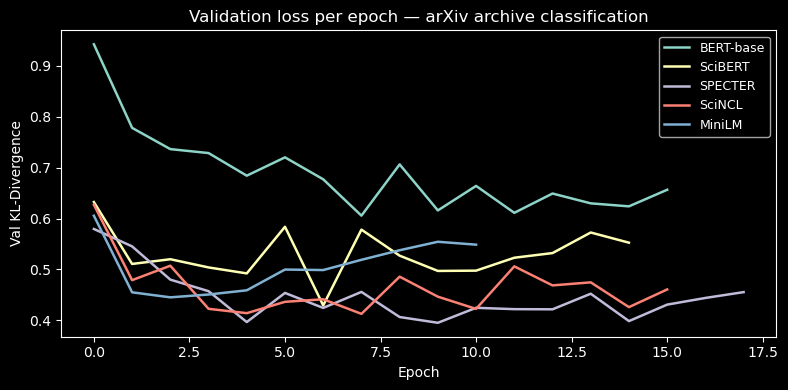

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
for name, hist in histories.items():
    ax.plot(hist.history['val_loss'], label=name, linewidth=1.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Val KL-Divergence')
ax.set_title('Validation loss per epoch — arXiv archive classification')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# § 10 — Metrics comparison

Two evaluation framings:

| Framing | Prediction | Ground truth | Metrics |
|---|---|---|---|
| **Argmax / multiclass** | `argmax(P)` | dominant archive index | accuracy, macro-F1 |
| **Multi-label / thresholded** | `P ≥ τ` | multi-hot `Y_raw` | macro-F1, micro-F1, subset accuracy, Hamming loss |

In [20]:
preds_prob = {}
for name, model in trained_models.items():
    preds_prob[name] = model.predict(embeddings[name][idx_te], verbose=0)

Y_te_raw = Y_raw[idx_te]
y_dom_te = y_dom[idx_te]

── Argmax / multiclass ──
           Accuracy  Macro-F1
Model                        
SciNCL       0.8689    0.8686
SciBERT      0.8600    0.8588
SPECTER      0.8578    0.8573
MiniLM       0.8400    0.8376
BERT-base    0.8067    0.8053


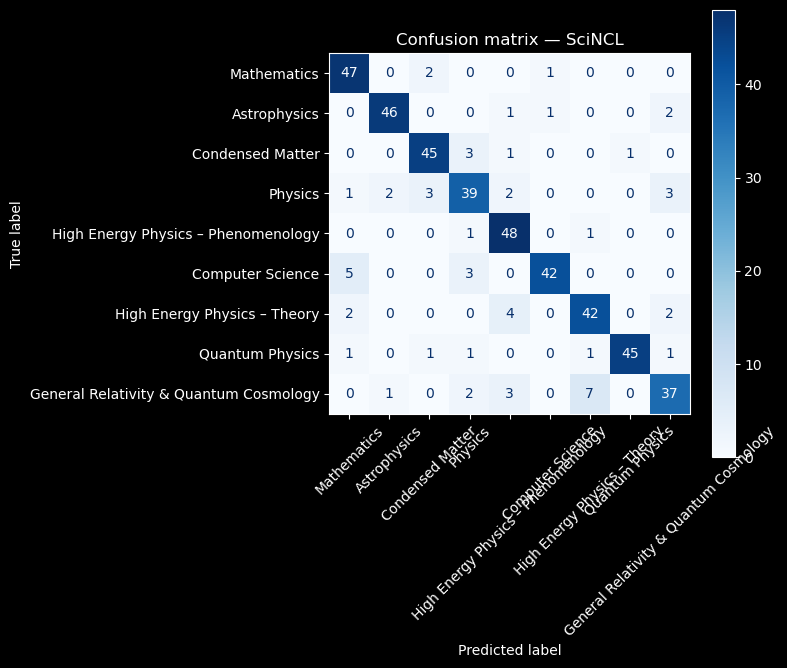


── Classification report (SciNCL) ──
                                        precision    recall  f1-score   support

                           Mathematics       0.84      0.94      0.89        50
                          Astrophysics       0.94      0.92      0.93        50
                      Condensed Matter       0.88      0.90      0.89        50
                               Physics       0.80      0.78      0.79        50
   High Energy Physics – Phenomenology       0.81      0.96      0.88        50
                      Computer Science       0.95      0.84      0.89        50
          High Energy Physics – Theory       0.82      0.84      0.83        50
                       Quantum Physics       0.98      0.90      0.94        50
General Relativity & Quantum Cosmology       0.82      0.74      0.78        50

                              accuracy                           0.87       450
                             macro avg       0.87      0.87      0.87       450


In [21]:
# ── Argmax / multiclass framing ──
records_argmax = []
for name, P in preds_prob.items():
    y_pred_dom = P.argmax(axis=1)
    acc = accuracy_score(y_dom_te, y_pred_dom)
    f1  = f1_score(y_dom_te, y_pred_dom, average='macro', zero_division=0)
    records_argmax.append({'Model': name, 'Accuracy': acc, 'Macro-F1': f1})

df_argmax = (
    pd.DataFrame(records_argmax)
    .set_index('Model')
    .sort_values('Macro-F1', ascending=False)
)
print("── Argmax / multiclass ──")
print(df_argmax.to_string(float_format='{:.4f}'.format))

# ── Confusion matrix + classification report for best model ──
best_name = df_argmax['Macro-F1'].idxmax()
best_pred = preds_prob[best_name].argmax(axis=1)

fig, ax = plt.subplots(figsize=(max(8, n_cats * 0.55), max(7, n_cats * 0.5)))
ConfusionMatrixDisplay.from_predictions(
    y_dom_te, best_pred,
    display_labels=topic_labels,
    cmap='Blues', ax=ax, xticks_rotation=45,
)
ax.set_title(f'Confusion matrix — {best_name}')
plt.tight_layout()
plt.show()

print(f"\n── Classification report ({best_name}) ──")
print(classification_report(
    y_dom_te, best_pred,
    target_names=topic_labels, zero_division=0,
))

# § 11 — Summary

## What we did
1. Loaded the full arXiv metadata snapshot (~3.08 M papers) from a JSON-lines file.
2. Normalised space-separated, hierarchical category codes to **unique top-level archives**:
   `cs.AI cs.LG` → `cs` (single label); `math.NA cs.NA` → `{cs, math}` (genuine cross-archive).
   After this collapse the vast majority of papers are **single-label** — the multi-label
   machinery handles the minority that span two or more archives without any special-casing.
3. Derived `CATS` as all archives with ≥ `N_PER_CAT` papers and set `TAU = 1/len(CATS)`.
4. **Equal-subsampled** 50 papers per dominant archive (~1 000 texts total) and built three label views:
   `Y_raw` (multi-hot) · `Y_dist` (row-normalised KL target) · `y_dom` (argmax for stratification & class weights).
5. Embedded every text with **five scientific transformer models** — mean-pool of last hidden state, 128-token truncation.
6. Trained a `Dense(256)→Dropout(0.3)→Dense(128)→softmax(n_archives)` Keras net per embedding
   with **KL-divergence** loss and inverse-frequency sample weights.
7. Evaluated under two framings:

| Framing | Prediction | Metrics |
|---|---|---|
| Argmax / multiclass | dominant archive index | accuracy, macro-F1, confusion matrix |
| Multi-label / thresholded at τ | binary via `P ≥ τ` | macro-F1, micro-F1, subset acc, Hamming loss |

## Model expectations
| Model | Why it may win |
|---|---|
| **SPECTER** (`allenai/specter`) | Pre-trained specifically to embed scientific papers (title+abstract); uses citation links as supervision signal |
| **SciNCL** (`malteos/scincl`) | SPECTER successor using citation-neighbourhood contrastive learning; strongest general scientific embeddings |
| **SciBERT** (`allenai/scibert_scivocab_uncased`) | BERT trained on Semantic Scholar corpus; strong general scientific baseline |
| **MiniLM** (384-dim) | Faster to embed; competitive despite half the dimension |
| **BERT-base** | General-domain lower bound |

## Extensions
- **Cache embeddings:** `np.save(f'{name}.npy', E)` then `np.load(...)` — enables larger subsamples (200–500/archive) without re-running the slow pipeline.
- **CLS pooling:** replace `out.mean(axis=0)` with `out[0]` — sometimes outperforms mean-pool.
- **Subcategory labels:** use the full `cs.CV`, `math.AP` codes for a harder 100+-class task.
- **`sentence-transformers` library:** call SPECTER/SciNCL via `.encode(texts, batch_size=32)` — 5–10× faster than the HF pipeline loop used here.
- **Top-k threshold:** choose k=1 (argmax) or k=2 dynamically rather than a fixed τ.